# Online Store Sales Analysis

In [2]:
import numpy as np
import pandas as pd
import  matplotlib.pyplot as plt
from statistics import mode

In [3]:


sales = pd.DataFrame({
    "Order_ID": range(101,116),
    "Category": [
        "Electronics","Clothing","Electronics","Furniture",
        "Clothing","Electronics","Furniture","Clothing",
        "Furniture","Electronics","Clothing","Furniture",
        "Electronics","Furniture","Clothing"
    ],
    "Amount": [
        250,80,300,450,120,
        275,500,95,420,310,
        150,390,280,460,130
    ]
})
sales

,Order_ID,Category,Amount
0,101,Electronics,250
1,102,Clothing,80
2,103,Electronics,300
3,104,Furniture,450
4,105,Clothing,120
5,106,Electronics,275
6,107,Furniture,500
7,108,Clothing,95
8,109,Furniture,420
9,110,Electronics,310


In [4]:
# mean sale amount
mean_sale_amount  = sales["Amount"].mean()
print("mean sales amount : ", mean_sale_amount.round(3))
# median sale amount
meadian_sale_Amount = sales["Amount"].median()
print("median sales amount : ",meadian_sale_Amount)
# sample standard deviation 
Samplt_Std =  np.std(sales["Amount"],ddof=1)
print("sample standard deviation : ", Samplt_Std.round(3))
# sample varience
Sample_varience = np.var(sales["Amount"],ddof=1)
print("Sample varience : ",Sample_varience.round(3))

mean sales amount :  280.667
median sales amount :  280.0
sample standard deviation :  142.138
Sample varience :  20203.095


In [5]:
# Q1, Q3, and IQR.
Q1 = np.quantile(sales["Amount"],0.25)
print("quantile one : ",Q1)
Q3 = np.quantile(sales["Amount"],0.75)
print("quantile three : ",Q3)
IQR = Q3 - Q1
print("inter quartile range : ", IQR)

quantile one :  140.0
quantile three :  405.0
inter quartile range :  265.0


In [6]:
# detect outliers 
IQR = Q3 - Q1
print("inter quartile range : ",IQR)
# lower bound 
lower_bound = Q1 - (1.5 * IQR)
print("lower bound : ", lower_bound)
# upper bound 
upper_bound = Q3 + (1.5 * IQR)
print("upper bound : ", upper_bound)
# empty list
outlier = []
for i in sales["Amount"]:
   if (i < lower_bound) | ( i > upper_bound):
      outlier.append(i)
print(outlier)

inter quartile range :  265.0
lower bound :  -257.5
upper bound :  802.5
[]


In [7]:
# calculate the probablity of amount greater than 300
total = len(sales["Amount"])
greater_300 = np.sum(sales["Amount"] > 300)
p_greater_300 = greater_300/total
print("probablity of amount greater than 300 :  ", p_greater_300)
# average sales amount for each category
avg_sal_amo = sales.groupby("Category")["Amount"].mean()
print("average sale amount for each category : ", avg_sal_amo)

probablity of amount greater than 300 :   0.4
average sale amount for each category :  Category
Clothing       115.0
Electronics    283.0
Furniture      444.0
Name: Amount, dtype: float64


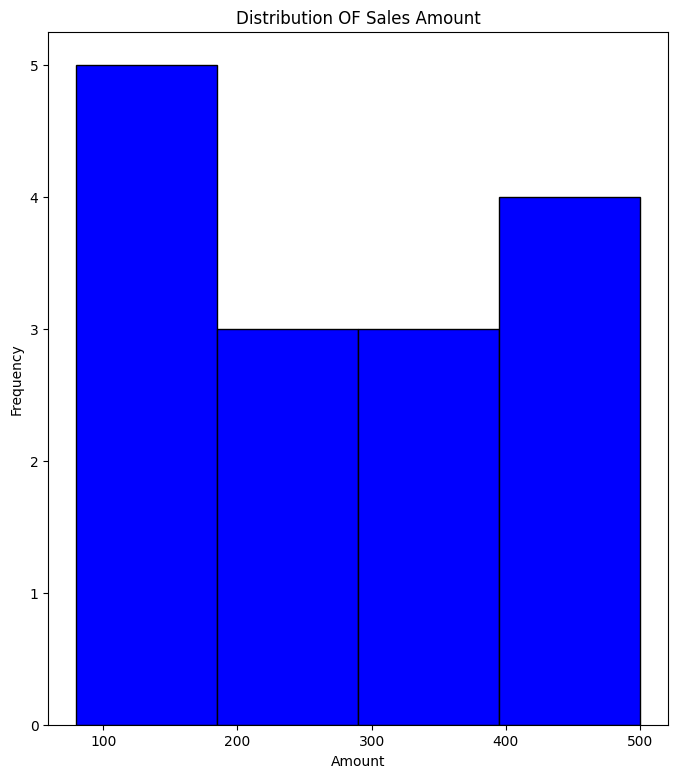

In [8]:
# histogram of sales amount
plt.figure(figsize=(8,9))
plt.hist(sales["Amount"],bins=4,color="blue",edgecolor="black")
plt.title("Distribution OF Sales Amount")
plt.xlabel("Amount")
plt.ylabel("Frequency")
plt.show()

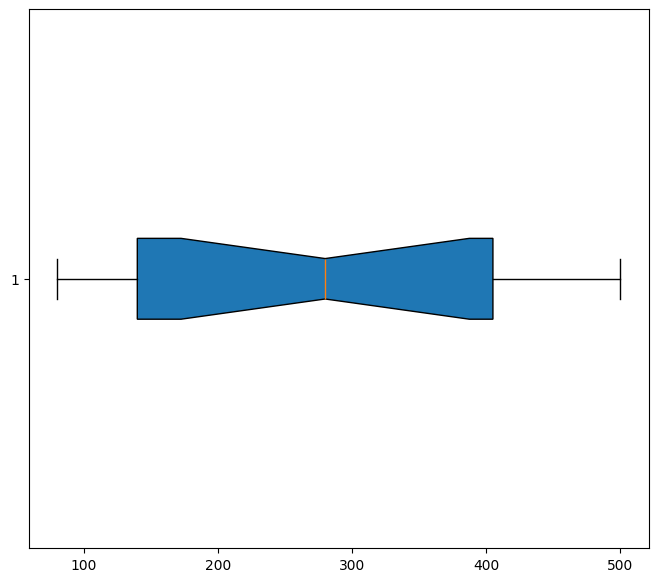

In [9]:
# box plot
plt.figure(figsize=(8,7))
plt.boxplot(sales["Amount"],vert=False,patch_artist=True,notch=True)
plt.show()

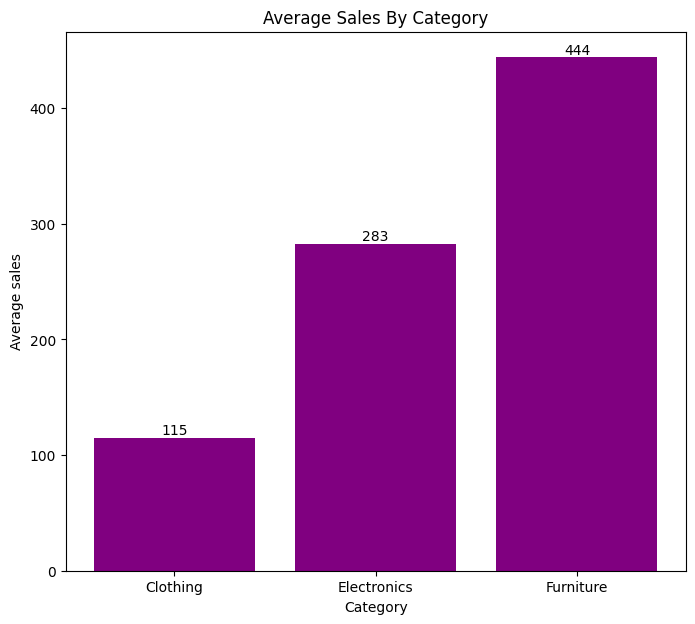

In [19]:
# bar chart showing average sales by category
avg_sal_amo = sales.groupby("Category")["Amount"].mean()
plt.figure(figsize=(8,7))
bar = plt.bar(avg_sal_amo.index,avg_sal_amo.values,color= "purple")
plt.bar_label(bar)
plt.title("Average Sales By Category")
plt.xlabel("Category")
plt.ylabel("Average sales")
plt.show()
